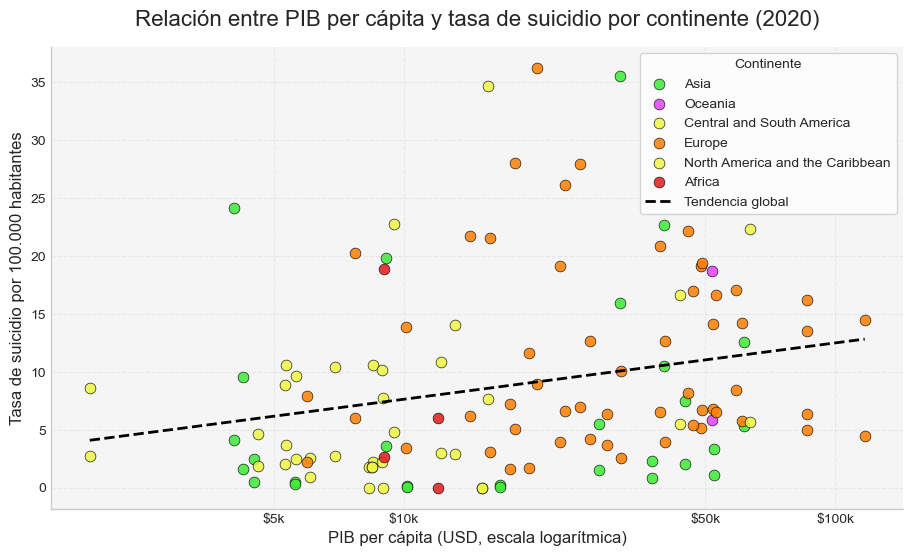

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv("suicide_rates_1990-2022.csv")

df = df[df["Year"] == 2020]

df = df.dropna(subset=["GDPPerCapita", "DeathRatePer100K", "RegionName"])

plt.figure(figsize=(11, 6))


colors = {
    "Africa": "#e41a1c",     
    "Americas": "#7cc4ff",   
    "Asia": "#3ceb36",       
    "Europe": "#ff7f00",      
    "Oceania": "#e540ff"     
}

# Scatter por continente
for region in df["RegionName"].unique():
    subset = df[df["RegionName"] == region]
    
    plt.scatter(
        subset["GDPPerCapita"],
        subset["DeathRatePer100K"],
        label=region,
        color=colors.get(region, "#EEF741"),
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        s=60
    )

# Escala logarítmica
plt.xscale("log")

ticks = [1000, 5000, 10000, 50000, 100000]
labels = ["$1k", "$5k", "$10k", "$50k", "$100k"]
plt.xticks(ticks, labels)

x = df["GDPPerCapita"]
y = df["DeathRatePer100K"]

coef = np.polyfit(np.log(x), y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = trend(np.log(x_line))

plt.plot(
    x_line, y_line,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Tendencia global"
)

plt.title(
    "Relación entre PIB per cápita y tasa de suicidio por continente (2020)",
    fontsize=16,
    pad=15
)

plt.xlabel("PIB per cápita (USD, escala logarítmica)", fontsize=12)
plt.ylabel("Tasa de suicidio por 100.000 habitantes", fontsize=12)

plt.legend(title="Continente", frameon=True)

plt.grid(True, linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#f5f5f5")

plt.savefig("grafico.png", dpi=300, bbox_inches="tight")

plt.show()